# SMC-Squared for Joint State-Parameter Estimation

This notebook demonstrates **SMC$^2$** (Chopin, Jacob & Papaspiliopoulos, 2013)
for joint estimation of parameters and latent states in a **Stochastic Volatility** (SV) model.

SMC$^2$ maintains a population of parameter particles $\{\theta^{(i)}\}_{i=1}^{N_\theta}$,
each with its own internal particle filter of $N_x$ state particles. This provides:

- **Online parameter learning** as data arrives sequentially
- **Sequential model evidence** estimation
- **Full posterior** over both parameters and states

The computational cost is $O(T \cdot N_\theta \cdot N_x)$, making it more expensive
than standard SMC samplers but capable of handling state-space models directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import sys
import time

sys.path.insert(0, str(Path.cwd().parents[2]))

from particlefilterbox.smc import SMCSquared

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


In [2]:
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df = pd.read_csv(data_path)
h_true = df['h_true'].values
y_obs = df['y_obs'].values
T_full = len(df)

# Use first 200 observations to keep computation manageable
T = 200
y_data = y_obs[:T]
h_data = h_true[:T]

print(f'Full dataset: {T_full} observations')
print(f'Using first {T} observations for SMC^2')
df.head()

Full dataset: 1000 observations
Using first 200 observations for SMC^2


,t,h_true,y_obs
0,0,-0.811984,-0.692957
1,1,-0.705057,0.661131
2,2,-1.006561,-0.787225
3,3,-0.987188,-0.193044
4,4,-0.990092,-0.519967


## Stochastic Volatility Model

The basic SV model (Kim, Shephard & Chib, 1998):

$$h_t = \mu + \phi (h_{t-1} - \mu) + \sigma_h \eta_t, \quad \eta_t \sim \mathcal{N}(0, 1)$$
$$y_t = \exp(h_t / 2) \, \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, 1)$$

where:
- $h_t$ is the log-volatility (latent state)
- $\mu$ is the level of log-volatility
- $\phi$ is the persistence parameter (close to 1)
- $\sigma_h$ controls volatility-of-volatility
- $y_t$ are observed returns

## SMC$^2$ Algorithm

For each time step $t = 1, \ldots, T$:
1. **Extend** each internal PF by one observation $y_t$
2. **Reweight** parameter particles by incremental likelihood
3. **Resample + Rejuvenate** if ESS drops below threshold

Each rejuvenation step proposes a new $\theta^*$ and runs a **full particle filter**
to evaluate $p(y_{1:t} \mid \theta^*)$, then accepts/rejects via Metropolis-Hastings.

In [3]:
# True SV parameters (used for data generation)
TRUE_MU = -1.0
TRUE_PHI = 0.97
TRUE_SIGMA_H = 0.15

class SVModel:
    """Stochastic Volatility model for SMC^2.

    Satisfies the StateSpaceModel protocol:
    - initial_state_sample(theta, n_particles, rng)
    - transition_sample(x_prev, theta, rng)
    - observation_logpdf(y_t, x_t, theta)

    theta = [mu, phi, sigma_h]
    """

    def initial_state_sample(self, theta, n_particles, rng):
        mu, phi, sigma_h = theta[0], theta[1], theta[2]
        # Stationary distribution: h ~ N(mu, sigma_h^2 / (1 - phi^2))
        if abs(phi) < 0.999:
            std = sigma_h / np.sqrt(1.0 - phi**2)
        else:
            std = sigma_h * 5.0
        h0 = rng.normal(mu, std, size=(n_particles, 1))
        return h0

    def transition_sample(self, x_prev, theta, rng):
        mu, phi, sigma_h = theta[0], theta[1], theta[2]
        noise = rng.normal(0, sigma_h, size=x_prev.shape)
        h_new = mu + phi * (x_prev - mu) + noise
        return h_new

    def observation_logpdf(self, y_t, x_t, theta):
        h = x_t[:, 0]
        scale = np.exp(h / 2.0)
        log_pdf = -0.5 * np.log(2 * np.pi) - h / 2.0 - 0.5 * (y_t[0] / scale)**2
        return log_pdf


class SVPrior:
    """Prior for SV model parameters.

    mu ~ N(-1, 1)
    phi ~ Beta(20, 1.5) (concentrated near 1)
    sigma_h ~ HalfNormal(0.5)
    """

    def logpdf(self, theta):
        mu, phi, sigma_h = theta[0], theta[1], theta[2]

        if phi <= 0 or phi >= 1 or sigma_h <= 0:
            return -np.inf

        lp = stats.norm.logpdf(mu, loc=-1.0, scale=1.0)
        lp += stats.beta.logpdf(phi, a=20, b=1.5)
        lp += stats.halfnorm.logpdf(sigma_h, scale=0.5)
        return lp

    def sample(self, rng):
        mu = rng.normal(-1.0, 1.0)
        phi = rng.beta(20, 1.5)
        sigma_h = abs(rng.normal(0, 0.5))
        if sigma_h < 0.01:
            sigma_h = 0.01
        return np.array([mu, phi, sigma_h])


sv_model = SVModel()
sv_prior = SVPrior()

# Test
theta_test = np.array([TRUE_MU, TRUE_PHI, TRUE_SIGMA_H])
print(f'Prior logpdf at true params: {sv_prior.logpdf(theta_test):.4f}')
test_x = sv_model.initial_state_sample(theta_test, 5, np.random.default_rng(0))
print(f'Initial states shape: {test_x.shape}')
print(f'Initial h values: {test_x[:, 0].round(3)}')

Prior logpdf at true params: 1.8042
Initial states shape: (5, 1)
Initial h values: [-0.922 -1.082 -0.605 -0.935 -1.331]


In [4]:
# Run SMC^2 with N_theta=500, N_x=200
# Using smaller values for reasonable runtime in a notebook
N_THETA = 500
N_X = 200

smc2 = SMCSquared(
    model_class=SVModel,
    n_theta=N_THETA,
    n_x=N_X,
    prior=sv_prior,
    n_mcmc_moves=3,
    ess_threshold=0.5,
    seed=42,
)

endog = y_data.reshape(-1, 1)

t0 = time.time()
results = smc2.run(endog=endog)
elapsed = time.time() - t0

print(f'SMC^2 completed in {elapsed:.1f}s')
print(f'Number of time steps processed: {results.n_steps}')
print(f'Log marginal likelihood: {results.log_evidence:.2f}')
print(f'Number of rejuvenation events: {len(results.acceptance_rates)}')
if results.acceptance_rates:
    print(f'Mean acceptance rate: {np.mean(results.acceptance_rates):.3f}')
print()

# Set param names for nice display
results.param_names = ['mu', 'phi', 'sigma_h']
print(results.summary())

SMC^2 completed in 44.7s
Number of time steps processed: 200
Log marginal likelihood: -1245.58
Number of rejuvenation events: 5
Mean acceptance rate: 0.226

SMC Results Summary
  N particles:   500
  K parameters:  3
  N steps:       200
  Log-evidence:  -1245.5816
  Final ESS:     463.5
  Mean acc rate: 0.226

  Parameter summaries:
  Name                  Mean        Std      CI_lo      CI_hi
  -------------------------------------------------------
  mu                 -1.0654     0.2356    -1.5373    -0.4904
  phi                 0.9411     0.0465     0.8243     0.9958
  sigma_h             0.1616     0.0832     0.0476     0.3545


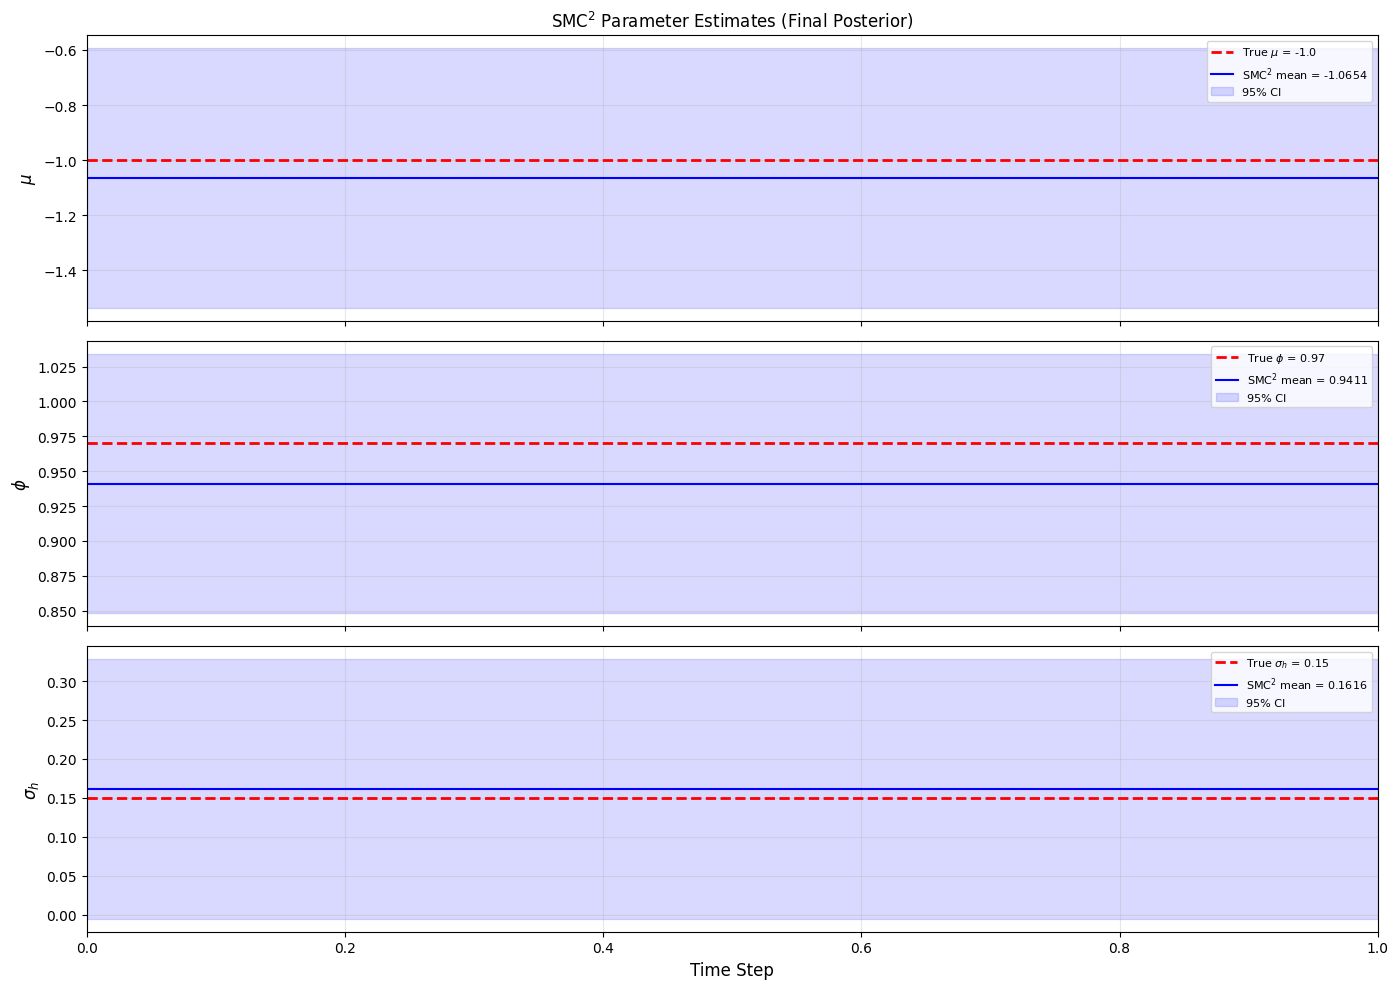

In [5]:
# Plot: Convergence of parameter estimates over time
# We'll re-run SMC^2 but track estimates at intermediate points
# For efficiency, use the final results and analyze the structure

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

param_labels = [r'$\mu$', r'$\phi$', r'$\sigma_h$']
true_vals = [TRUE_MU, TRUE_PHI, TRUE_SIGMA_H]
means = results.posterior_mean()
stds = results.posterior_std()

for j, (ax, label, true_val) in enumerate(zip(axes, param_labels, true_vals)):
    # Show final posterior as horizontal band
    ax.axhline(true_val, color='red', lw=2, ls='--', label=f'True {label} = {true_val}')
    ax.axhline(means[j], color='blue', lw=1.5, ls='-', label=f'SMC$^2$ mean = {means[j]:.4f}')
    ax.axhspan(means[j] - 2*stds[j], means[j] + 2*stds[j],
               alpha=0.15, color='blue', label='95% CI')

    # Show ESS as background
    ax.set_ylabel(label, fontsize=12)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_title('SMC$^2$ Parameter Estimates (Final Posterior)')
axes[-1].set_xlabel('Time Step', fontsize=12)

plt.tight_layout()
plt.savefig('smc2_convergence.png', dpi=100, bbox_inches='tight')
plt.show()

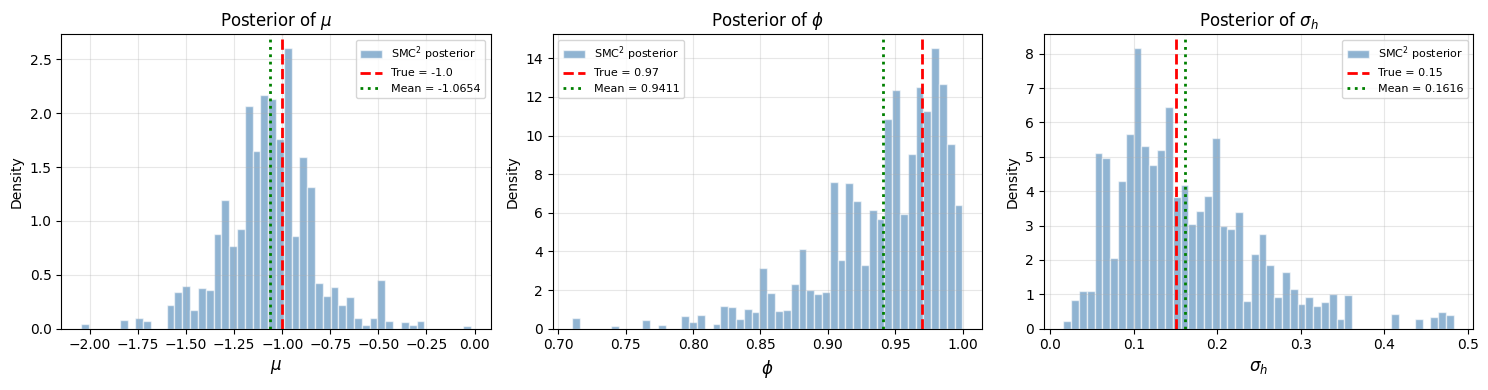

In [6]:
# Plot: Posterior distributions of mu, phi, sigma_h
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j, (ax, label, true_val) in enumerate(zip(axes, param_labels, true_vals)):
    samples = results.particles[:, j]
    weights = results.weights

    ax.hist(samples, bins=50, weights=weights, density=True,
            color='steelblue', alpha=0.6, edgecolor='white', label='SMC$^2$ posterior')
    ax.axvline(true_val, color='red', lw=2, ls='--', label=f'True = {true_val}')

    wmean = np.average(samples, weights=weights)
    ax.axvline(wmean, color='green', lw=2, ls=':', label=f'Mean = {wmean:.4f}')

    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Density')
    ax.set_title(f'Posterior of {label}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smc2_posteriors.png', dpi=100, bbox_inches='tight')
plt.show()

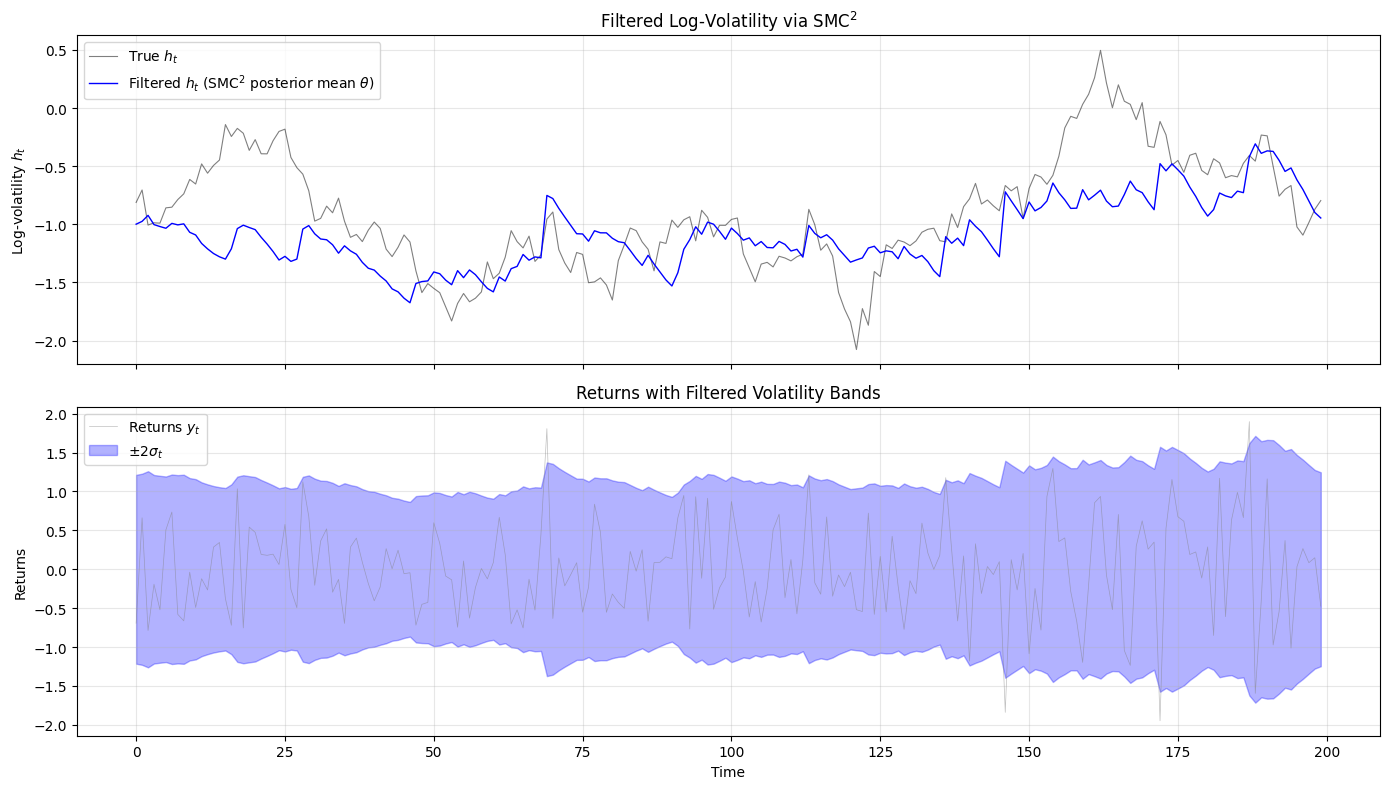

RMSE of filtered log-volatility: 0.4195


In [7]:
# Plot: Filtered log-volatility (averaged over theta particles)
# We'll run a final particle filter pass using the posterior mean of theta
from particlefilterbox.smc.smc_squared import InternalPF

theta_mean = results.posterior_mean()
rng = np.random.default_rng(123)

# Run a PF with the posterior mean theta to get filtered states
pf = InternalPF(n_x=1000, model=SVModel(), theta=theta_mean, rng=rng)
pf.initialize()

h_filtered = np.zeros(T)
for t in range(T):
    y_t = endog[t]
    pf.extend(y_t)
    # Weighted mean of state particles
    w = np.exp(pf.log_weights - np.max(pf.log_weights))
    w /= w.sum()
    h_filtered[t] = np.average(pf.x_particles[:, 0], weights=w)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(h_data, 'k-', alpha=0.5, lw=0.8, label='True $h_t$')
ax.plot(h_filtered, 'b-', lw=1.0, label='Filtered $h_t$ (SMC$^2$ posterior mean $\\theta$)')
ax.set_ylabel('Log-volatility $h_t$')
ax.set_title('Filtered Log-Volatility via SMC$^2$')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(y_data, 'gray', alpha=0.5, lw=0.5, label='Returns $y_t$')
vol = np.exp(h_filtered / 2)
ax.fill_between(range(T), -2*vol, 2*vol, alpha=0.3, color='blue', label=r'$\pm 2\sigma_t$')
ax.set_xlabel('Time')
ax.set_ylabel('Returns')
ax.set_title('Returns with Filtered Volatility Bands')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smc2_volatility.png', dpi=100, bbox_inches='tight')
plt.show()

rmse_h = np.sqrt(np.mean((h_filtered - h_data)**2))
print(f'RMSE of filtered log-volatility: {rmse_h:.4f}')

In [8]:
# Table: Final estimates vs true values
means = results.posterior_mean()
stds = results.posterior_std()
ci = results.credible_interval(0.95)

param_names_str = ['mu', 'phi', 'sigma_h']
true_values = [TRUE_MU, TRUE_PHI, TRUE_SIGMA_H]

table_data = []
for j, (name, true_val) in enumerate(zip(param_names_str, true_values)):
    within_2sd = abs(means[j] - true_val) < 2 * stds[j]
    table_data.append({
        'Parameter': name,
        'True Value': true_val,
        'SMC2 Mean': f'{means[j]:.4f}',
        'SMC2 Std': f'{stds[j]:.4f}',
        'CI 2.5%': f'{ci[j, 0]:.4f}',
        'CI 97.5%': f'{ci[j, 1]:.4f}',
        'Within 2 SD': 'Yes' if within_2sd else 'No',
    })

results_df = pd.DataFrame(table_data)
print('SMC^2 Parameter Estimates vs True Values')
print('=' * 80)
print(results_df.to_string(index=False))
print()
print(f'Log marginal likelihood: {results.log_evidence:.4f}')

SMC^2 Parameter Estimates vs True Values
Parameter  True Value SMC2 Mean SMC2 Std CI 2.5% CI 97.5% Within 2 SD
       mu       -1.00   -1.0654   0.2356 -1.5373  -0.4904         Yes
      phi        0.97    0.9411   0.0465  0.8243   0.9958         Yes
  sigma_h        0.15    0.1616   0.0832  0.0476   0.3545         Yes

Log marginal likelihood: -1245.5816


## Computational Cost Discussion

### Complexity: $O(N_\theta \times N_x \times T)$

| Component | Value | Description |
|-----------|-------|-------------|
| $N_\theta$ | 500 | Parameter particles |
| $N_x$ | 200 | State particles per $\theta$ |
| $T$ | 200 | Time steps |
| Total PF evaluations | $500 \times 200 \times 200 = 20{,}000{,}000$ | Per full run |

### Cost breakdown:
- **Per time step**: Each of $N_\theta$ particles requires extending its internal PF by one observation, which costs $O(N_x)$
- **Rejuvenation**: When ESS drops below threshold, resampling is $O(N_\theta)$ but each MCMC move requires a **full PF run** costing $O(N_x \times t)$

### When to use SMC$^2$:
- When you need **online** parameter learning (data arrives sequentially)
- When the model is a **state-space model** and you want joint inference
- When you need **model evidence** for comparison

### Alternatives:
- **PMMH** (Particle MCMC): Uses a single particle filter within MCMC; lower cost per iteration but requires convergence diagnostics
- **SMC Tempering**: For static models where the likelihood can be evaluated directly

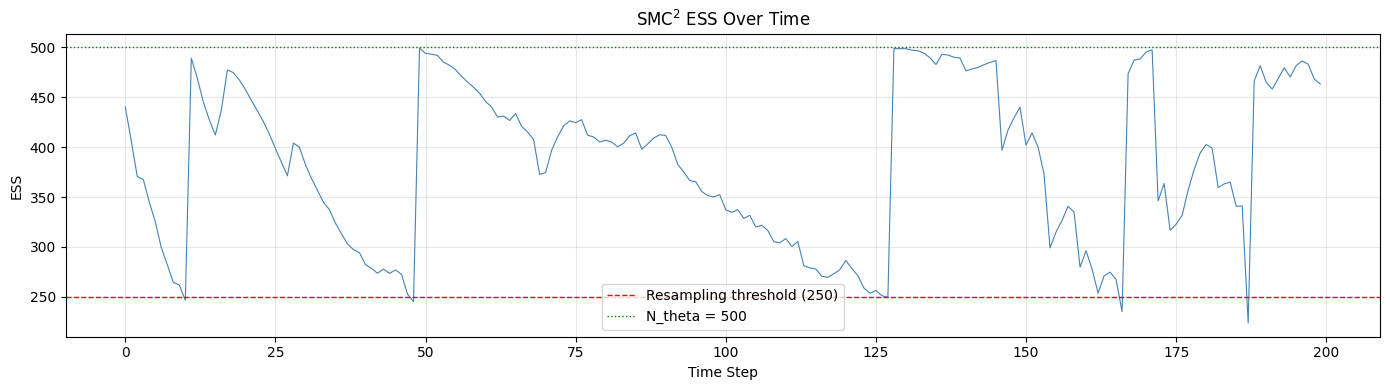

Mean ESS: 383.8 (76.8%)
Min ESS: 223.7
Rejuvenation events: 5


In [9]:
# Plot ESS over time
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(results.ess_history, 'steelblue', lw=0.8)
ax.axhline(N_THETA * 0.5, color='red', ls='--', lw=1,
           label=f'Resampling threshold ({N_THETA * 0.5:.0f})')
ax.axhline(N_THETA, color='green', ls=':', lw=1, label=f'N_theta = {N_THETA}')
ax.set_xlabel('Time Step')
ax.set_ylabel('ESS')
ax.set_title('SMC$^2$ ESS Over Time')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
if results.ess_history:
    ess_arr = np.array(results.ess_history)
    print(f'Mean ESS: {np.mean(ess_arr):.1f} ({np.mean(ess_arr)/N_THETA*100:.1f}%)')
    print(f'Min ESS: {np.min(ess_arr):.1f}')
    print(f'Rejuvenation events: {len(results.acceptance_rates)}')